In [1]:
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.model_selection import train_test_split

2024-04-22 11:15:25.872486: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-04-22 11:15:25.969878: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-22 11:15:25.969958: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-22 11:15:25.977703: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-22 11:15:26.001862: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-04-22 11:15:26.003330: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
tf.get_logger().setLevel('ERROR')

# bert_model_name = 'small_bert/bert_en_uncased_L-4_H-512_A-8'
bert_model_name = 'small_bert/bert_en_uncased_L-2_H-128_A-2'
# bert_model_name = 'electra_base'

map_name_to_handle = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_L-12_H-768_A-12/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_L-12_H-768_A-12/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-768_A-12/1',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_base/2',
    'electra_small':
        'https://tfhub.dev/google/electra_small/2',
    'electra_base':
        'https://tfhub.dev/google/electra_base/2',
    'experts_pubmed':
        'https://tfhub.dev/google/experts/bert/pubmed/2',
    'experts_wiki_books':
        'https://tfhub.dev/google/experts/bert/wiki_books/2',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/talkheads_ggelu_bert_en_base/1',
}

map_model_to_preprocess = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_preprocess/3',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_preprocess/3',
    'electra_small':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'electra_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_pubmed':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_wiki_books':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
}

tfhub_handle_encoder = map_name_to_handle[bert_model_name]
tfhub_handle_preprocess = map_model_to_preprocess[bert_model_name]

print(f'BERT model selected           : {tfhub_handle_encoder}')
print(f'Preprocess model auto-selected: {tfhub_handle_preprocess}')

print('Loading...')
bert_preprocess_model = hub.KerasLayer(tfhub_handle_preprocess)

print('Processing...')
text_test = ['this is such an amazing movie!']
text_preprocessed = bert_preprocess_model(text_test)

print(f'Keys       : {list(text_preprocessed.keys())}')
print(f'Shape      : {text_preprocessed["input_word_ids"].shape}')
print(f'Word Ids   : {text_preprocessed["input_word_ids"][0, :12]}')
print(f'Input Mask : {text_preprocessed["input_mask"][0, :12]}')
print(f'Type Ids   : {text_preprocessed["input_type_ids"][0, :12]}')

bert_model = hub.KerasLayer(tfhub_handle_encoder)

bert_results = bert_model(text_preprocessed)

print(f'Loaded BERT: {tfhub_handle_encoder}')
print(f'Pooled Outputs Shape:{bert_results["pooled_output"].shape}')
print(f'Pooled Outputs Values:{bert_results["pooled_output"][0, :12]}')
print(f'Sequence Outputs Shape:{bert_results["sequence_output"].shape}')
print(f'Sequence Outputs Values:{bert_results["sequence_output"][0, :12]}')

BERT model selected           : https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1
Preprocess model auto-selected: https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3
Loading...
Processing...
Keys       : ['input_mask', 'input_type_ids', 'input_word_ids']
Shape      : (1, 128)
Word Ids   : [ 101 2023 2003 2107 2019 6429 3185  999  102    0    0    0]
Input Mask : [1 1 1 1 1 1 1 1 1 0 0 0]
Type Ids   : [0 0 0 0 0 0 0 0 0 0 0 0]
Loaded BERT: https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1
Pooled Outputs Shape:(1, 128)
Pooled Outputs Values:[-0.9999946   0.14341968 -0.9989779   0.9951449  -0.99974567  0.9131291
 -0.9961581  -0.97097486  0.09740014  0.01907066 -0.8488175  -0.09385542]
Sequence Outputs Shape:(1, 128, 128)
Sequence Outputs Values:[[-0.437236   -1.0138295  -2.3744745  ... -0.7589703  -2.0910308
  -0.2580995 ]
 [-1.3369716  -0.36880207  0.57868755 ... -2.1810157  -1.7530916
  -0.09555069]
 [-1.0607051  -0.30371016  0.34461278 

In [3]:
from kafka import KafkaConsumer, TopicPartition
import json
import numpy as np
from datetime import datetime, timedelta
import re

In [4]:
kafka_url = ['kafka9-0.kafka9-headless.default.svc.cluster.local:9093','kafka9-1.kafka9-headless.default.svc.cluster.local:9093','kafka9-2.kafka9-headless.default.svc.cluster.local:9093']
topic = 'BASKERVILLEHALL_4'

In [5]:
host = 'kavkaz-uzel.eu'
datetime_format = '%Y-%m-%d %H:%M:%S'

In [ ]:
def is_bot_ua(ua):
    ua_lowercase = ua.lower()
    return 'bot' in ua_lowercase or 'spider' in ua_lowercase or 'crawl' in ua_lowercase

def is_bot(session):
    return session['primary_session'] == True or is_bot_ua(session['ua'])

In [17]:
def read_sessions(host, datetime_format, max_size=3000, session_type='all'):
    partitions = {
        'zhitomir.info': 1,
        'urban-pushkino.ru': 0,
        'dev.emawpb.org': 0,
        'palestinechronicle.com': 1,
        'equalit.ie': 0,
        'lexota.org': 0,
        'kavkaz-uzel.eu': 0,
        'amp.kavkaz-uzel.eu': 2,
        'indymedia.nl': 0,
        'btselem.org': 0,
        'verafiles.org': 1,
        'telegraf.in.ua': 2,
        'gubernia.com': 1
    }
    partition = partitions[host]
    consumer = KafkaConsumer(
        bootstrap_servers=kafka_url,
        group_id='grue_ae'
    )
    print(f'Reading from kafka. Host = {host} ... partition = {partition}')
    num = 0
    sessions = []
    ips = []

    consumer.assign([TopicPartition(topic, partition)])
    consumer.seek_to_beginning()
    complete = False
    read = 0
    ts_now = datetime.now()
    while not complete:
        raw_messages = consumer.poll(timeout_ms=1000, max_records=5000)

        for topic_partition, messages in raw_messages.items():
            for message in messages:
                if message.value is None :
                    continue
                if message.key is None:
                    continue
                session = json.loads(message.value.decode("utf-8"))
                ts = datetime.strptime(session['start'], datetime_format)
                # print(ts, ts_now, (ts_now - ts).total_seconds(), 2 * 60 * 60)
                # break
                # if (ts_now - ts).total_seconds() > 1 * 60 * 60:
                #     continue

                # if read % 10000 == 0:
                #     print(ts)
                read += 1

                if message.key.decode("utf-8") != host:
                    continue
                if session_type == 'primary':
                    if not session['primary_session']:
                        continue
                elif session_type == 'regular':
                    if session['primary_session']:
                        continue

                if is_bot(session):
                    continue
                
                sessions.append(session)
                ips.append(session['ip']) 
                num += 1
                if num % 100 == 0:
                    print(f'{num} sessions read', session['end'], message.timestamp)

                if num == max_size:
                    complete = True
                    break
            
    return sessions, ips

In [18]:
sessions, ips = read_sessions(
    host=host, 
    max_size=5000,
    datetime_format=datetime_format,
    session_type='all'
)

Reading from kafka. Host = kavkaz-uzel.eu ... partition = 0
100 sessions read 2024-04-21 19:43:29 1713728612205
200 sessions read 2024-04-21 19:48:51 1713728934173
300 sessions read 2024-04-21 19:55:00 1713729302725
400 sessions read 2024-04-21 19:58:19 1713729501586
500 sessions read 2024-04-21 20:01:53 1713729716369
600 sessions read 2024-04-21 20:08:13 1713730095436
700 sessions read 2024-04-21 20:12:40 1713730363132
800 sessions read 2024-04-21 20:19:21 1713730764277
900 sessions read 2024-04-21 20:23:45 1713731027348
1000 sessions read 2024-04-21 20:30:38 1713731440433
1100 sessions read 2024-04-21 20:39:29 1713731971166
1200 sessions read 2024-04-21 20:45:09 1713732312164
1300 sessions read 2024-04-21 20:52:06 1713732729485
1400 sessions read 2024-04-21 21:01:21 1713733284162
1500 sessions read 2024-04-21 21:06:41 1713733604549
1600 sessions read 2024-04-21 21:13:13 1713733995572
1700 sessions read 2024-04-21 21:21:42 1713734504358
1800 sessions read 2024-04-21 21:32:02 171373512

In [19]:
ids = {}
for s in sessions:
    ids[s['session_id']] = ids.get(s['session_id'], 0) + 1
len(ids)

1494

In [20]:
for id, count in ids.items():
    if count > 2:
        print(id, count)
        break

9zy8bWZ3tLQAAAAAZiV5XA%3D%3D 4


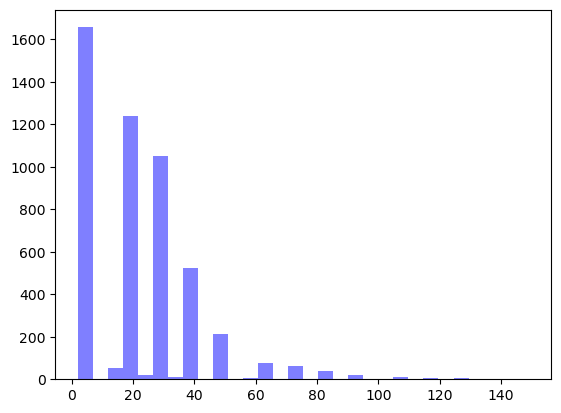

In [21]:
import matplotlib.pyplot as plt
n, bins, patches = plt.hist([len(s['requests']) for s in sessions], facecolor='blue', alpha=0.5, bins=30)
plt.rcParams["figure.figsize"] = (22,5)
plt.show()

In [22]:
for s in sessions:
    if s['duration'] > 20:
        print(s['duration'], s['ip'])
        for r in s['requests']:
            print(r['ts'], r['url'])
        break
        

37.0 91.5.21.23
2024-04-21 19:38:57 /frontend/customisation.json
2024-04-21 19:39:34 /system/uploads/blog_post_image/image/0028/287393/Voskepar-1-1.jpg


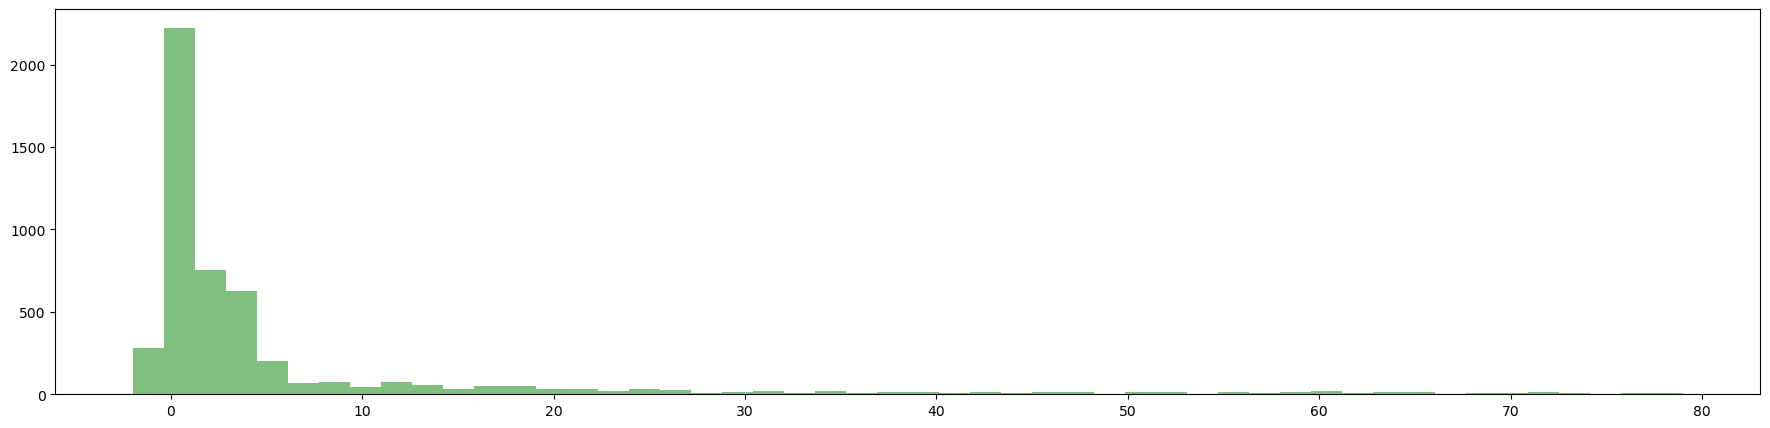

In [23]:
n, bins, patches = plt.hist([s['duration'] for s in sessions], facecolor='green', alpha=0.5, bins=50)
plt.rcParams["figure.figsize"] = (22,5)
plt.show()

In [24]:
num_primary = 0
for s in sessions:
    if s['primary_session'] == True:
        num_primary += 1
print(f'Number of primary sessions = {num_primary} - {num_primary*100.0/len(sessions)}%')

Number of primary sessions = 0 - 0.0%


In [25]:
'bot' in 'Bot'.lower()

True

In [26]:
num_bot = 0
for s in sessions:
    if is_bot(s):
        num_bot += 1
print(f'Number of bot sessions = {num_bot} - {num_bot*100.0/len(sessions)}%')

Number of bot sessions = 0 - 0.0%


In [27]:
for s in sessions:
    if s['primary_session'] == True:
        for r in s['requests']:
            print(r['ts'], r['url'])
        break

In [28]:
# for s in sessions:
#     if s['primary_session'] == True:
#         print(s)
#         break

In [29]:
for s in sessions:
    if s['requests'][0]['url'] == '/' and s['requests'][1]['url'] == '/' and s['requests'][w]['url'] == '/':
        print(s)
        break

In [30]:
import re
from urllib.parse import urlparse, unquote

def urls_to_text(urls, host):
    texts = []
    for url in urls:
        if url == '/':
            words = [host, 'home page']
        else:
            # Decode URL to convert %20, etc. into real characters
            url = unquote(url)
        
            # Parse the URL to isolate different parts
            parsed_url = urlparse(url)
        
            # Extract the subdomain, path, and query string
            # Assuming top-level domain and second-level domain are not 'real words'
            subdomain_path_query = parsed_url.netloc.split('.')[:-2] + parsed_url.path.split('/') + parsed_url.query.split('&')
        
            # Join these components into a single string, replacing delimiters with a space
            combined = ' '.join(subdomain_path_query).replace('-', ' ').replace('_', ' ')
        
            # Regular expression to extract words (alphanumeric characters)
            word_pattern = re.compile(r'\b[a-zA-Z0-9]+\b')
        
            # Find all words in the combined string
            words = word_pattern.findall(combined)
            # if len(words) == 0:
            #     words = ['host']
            words.insert(0, host)
        
        texts.append(' '.join([w for w in words if len(w) > 4]))
    return texts

# Example usage
print(urls_to_text(["/articles/vera-files-fact-check-katwiran-ng-palasyo-sa-hindi-pagsama-ng-anibersaryo-ng-people-power-bilang-holiday-nakaliligaw"], host))

print(urls_to_text(["/"], host))
print(urls_to_text(['/articles/103346'], host))
print(urls_to_text(['/nunoe.png'], host))


['kavkaz-uzel.eu articles files check katwiran palasyo hindi pagsama anibersaryo people power bilang holiday nakaliligaw']
['kavkaz-uzel.eu home page']
['kavkaz-uzel.eu articles 103346']
['kavkaz-uzel.eu nunoe']


In [31]:
def texts_to_vec(texts):
    print('Tokenizing...')
    text_preprocessed = bert_preprocess_model(texts)
    print('Embedding...')
    bert_results = bert_model(text_preprocessed)
    return bert_results["pooled_output"]    
    
def urls_to_vec(urls, host):
    return texts_to_vec(urls_to_text(urls, host))

print(urls_to_vec(
    ["/articles/vera-files-fact-check-katwiran-ng-palasyo-sa-hindi-pagsama-ng-anibersaryo-ng-people-power-bilang-holiday-nakaliligaw"], host)[0,0:12])

Tokenizing...
Embedding...
tf.Tensor(
[-0.9999854   0.21239336 -0.8032818   0.7037588  -0.9481289   0.80718046
 -0.74028486 -0.9733665   0.06953815  0.0915432  -0.18944877  0.07265834], shape=(12,), dtype=float32)


In [32]:
def preprocess_requests(requests):
    if len(requests) == 0:
        return requests

    parse_datetime = isinstance(requests[0]['ts'], str)
    timestamps = {}
    for r in requests:
        if parse_datetime:
            r['ts'] = datetime.strptime(r['ts'], datetime_format)

    # requests = sorted(requests, key=lambda x: x['ts'])
    # return requests
    
    for r in requests: 
        if r['ts'] not in timestamps:
            timestamps[r['ts']] = []
        timestamps[r['ts']].append(r)
    ordered_ts = [(ts, r) for ts, r in timestamps.items()]
    ordered_ts = sorted(ordered_ts, key=lambda x: x[0])
    
    return ordered_ts

def split_session(session, datetime_format):   
    ts_requests = preprocess_requests(session.get('requests', []))
    urls = []
    delays = []
    country = session['country']

    start = ts_requests[0][0]
    urls.append([r['url'] for r in ts_requests[0][1]])
    delays.append(0)
    for i in range(1, len(ts_requests)):
        ts, requests = ts_requests[i]
        urls.append([r['url'] for r in requests])
        delays.append((ts - ts_requests[i-1][0]).total_seconds())

    return urls, delays

# def split_session(session, datetime_format):   
    
#     requests = preprocess_requests(session.get('requests', []))
    
#     urls = []
#     delays = []
#     country = session['country']
        
#     start = requests[0]['ts']
#     urls.append(requests[0]['url'])
#     delays.append(0)
#     for i in range(1, len(requests)):
#         r = requests[i]
#         urls.append(r['url'])
#         delays.append((r['ts'] - requests[i-1]['ts']).total_seconds())

#     return urls, delays
        

In [33]:
u, d = split_session(sessions[0], datetime_format)
d

[0]

In [34]:
print(sum([len(preprocess_requests(s['requests'])) for s in sessions]))
print(sum([len(s['requests']) for s in sessions]))

19157
110643


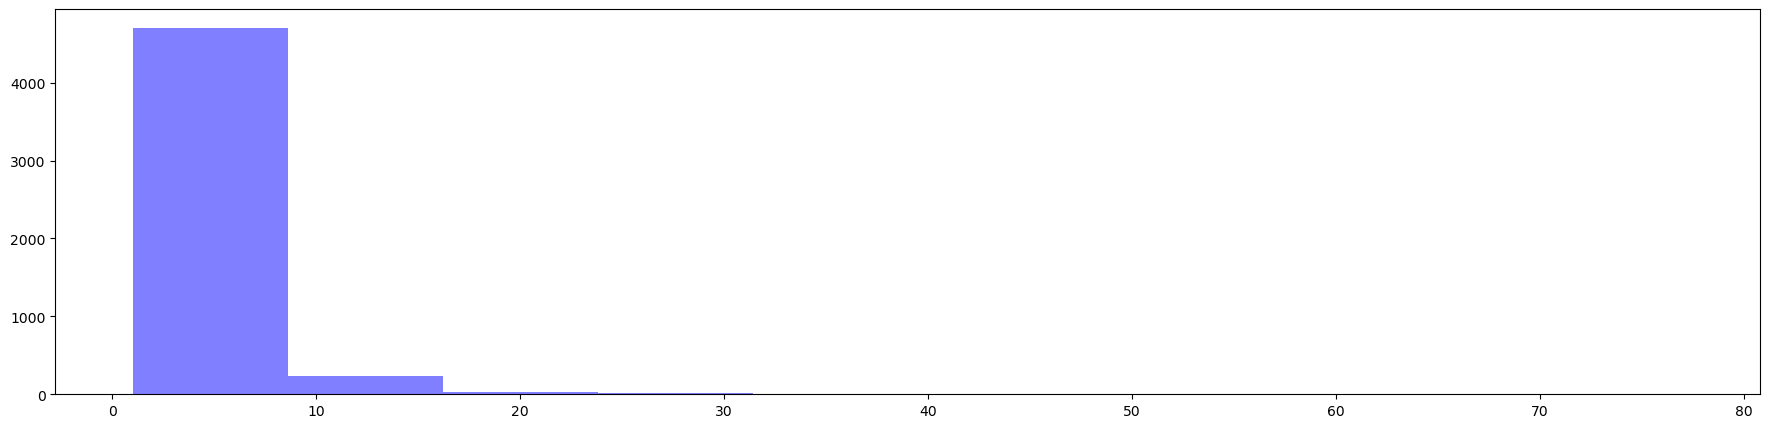

In [35]:
import matplotlib.pyplot as plt
n, bins, patches = plt.hist([len(preprocess_requests(s['requests'])) for s in sessions], facecolor='blue', alpha=0.5)
plt.rcParams["figure.figsize"] = (22,5)
plt.show()

In [36]:
from collections import OrderedDict
def get_unique_urls(sessions):
    urls = OrderedDict()
    index = 0
    for s in sessions:
        for r in s['requests']:
            url = r['url']
            if url not in urls:
                urls[url] = index
                index += 1
        
    return urls

def get_unique_urls_extra(sessions, unique_urls):
    urls_extra = OrderedDict()
    index = 0
    for s in sessions:
        for r in s['requests']:
            url = r['url']
            if url not in urls_extra and url not in unique_urls:
                urls_extra[url] = index
                index += 1
        
    return urls_extra
    
unique_urls = get_unique_urls(sessions)
print(len(unique_urls))
extra_urls = get_unique_urls_extra([{'requests':[{'url': '12345'}]}], unique_urls)
print(extra_urls)                                  

2774
OrderedDict([('12345', 0)])


In [37]:
unique_urls_vectors = urls_to_vec(list(unique_urls.keys()), host)
print('done.')

Tokenizing...
Embedding...
done.


In [91]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
def create_dataset(sessions, unique_urls, unique_urls_vectors, datetime_format, host, num_steps=1):
    X = []
    y = []
    i = 0
    urls = []
    delays = []
    lengths = []
    prime = []
    for session in sessions:
        u, d = split_session(session, datetime_format)
        urls += u
        delays += d
        lengths.append(len(u))
        prime.append(1.0 if session['primary_session'] else 0.5)
    vectors = []
    print('embedding extra urls...')
    urls_extra = get_unique_urls_extra(sessions, unique_urls)
    print(f'extra urls = {len(urls_extra)}')
    urls_extra_vectors = urls_to_vec(list(urls_extra.keys()), host)
    print('vectorizing urls...')
    
    # for url in urls:
    #     vector_average = []
    #     if url in unique_urls:
    #         vectors.append(unique_urls_vectors[unique_urls[url]])
    #     else:
    #         vectors.append(urls_extra_vectors[urls_extra[url]])
    for url_list in urls:
        vector_average = []
        for v in url_list:
            if v in unique_urls:
                vector_average.append(unique_urls_vectors[unique_urls[v]])
            else:
                vector_average.append(urls_extra_vectors[urls_extra[v]])
        vectors.append(np.average(vector_average, axis=0))
    
    print('unwrapping...')
    X = []
    X_delays = []
    X_prime = []
    index = 0
    for k in range(len(lengths)):
        l = lengths[k]
        X.append([vectors[index+i] for i in range(min(l, num_steps))])
        
        # X_delays.append([delays[index+i]/50.0 for i in range(min(l, num_steps))])
        # X_delays.append([delays[index+i] for i in range(min(l, num_steps))])
        X_delays.append([0 for i in range(min(l, num_steps))])
        
        # X_prime.append([prime[k] for i in range(min(l, num_steps))])
        X_prime.append([0 for i in range(min(l, num_steps))])
        
        index += l

    X = pad_sequences(X, padding='pre', dtype='float', value=0, maxlen=num_steps)
    X_delays = pad_sequences(X_delays, padding='pre', dtype='float', value=0, maxlen=num_steps)  
    X_prime = pad_sequences(X_prime, padding='pre', dtype='float', value=0, maxlen=num_steps)  
    return X, X_delays, X_prime

In [92]:
num_steps = 15

In [93]:
X, X_delays,X_prime = create_dataset(sessions, unique_urls, unique_urls_vectors, datetime_format, host, num_steps=num_steps)
print('Done.')

embedding extra urls...
extra urls = 0
Tokenizing...
Embedding...
vectorizing urls...
unwrapping...
Done.


In [94]:
X_delays[0:10]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [95]:
X_prime[0:10]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [96]:
len(sessions), len(X)

(5000, 5000)

In [97]:
X.shape

(5000, 15, 128)

In [98]:
import tensorflow as tf
from tensorflow.keras.layers import Input, GRU, Dense, Concatenate, Masking, RepeatVector, TimeDistributed
from tensorflow. keras.models import Model

# Input shape: (sequence_length, 101) where each time step contains 100 values + 1 value
dim1 = X.shape[2]
dim2 = 1
# dim3 = 1

input_1 = Input(shape=(num_steps, dim1), name='input_1')
input_2 = Input(shape=(num_steps, dim2), name='input_2')
# input_3 = Input(shape=(num_steps, dim3), name='input_3')

masked_1 = Masking(mask_value=0)(input_1)
masked_2 = Masking(mask_value=0)(input_2)
# masked_3 = Masking(mask_value=0)(input_3)
concatenated_inputs = Concatenate(axis=-1)([masked_1, masked_2])

encoded = GRU(256, activation='relu', return_sequences=False)(concatenated_inputs)
encoded = RepeatVector(num_steps)(encoded)  # Prepares the fixed-size vector for decoding

decoded = GRU(256, activation='relu', return_sequences=True)(encoded)

output_1 = TimeDistributed(Dense(dim1), name='output_1')(decoded)
output_2 = TimeDistributed(Dense(dim2), name='output_2')(decoded)
# output_3 = TimeDistributed(Dense(dim3), name='output_3')(decoded)

model = Model(inputs=[input_1, input_2], outputs=[output_1, output_2])

# Compile the model
model.compile(optimizer='adam',
              loss={'output_1': 'mean_squared_error', 
                    'output_2': 'mean_absolute_error', 
                    # 'output_3': 'mean_absolute_error'
                   },
              loss_weights={'output_1': 300.0, 'output_2': 1.0, 
                            # 'output_3': 1.0
                           }
)

# Print model summary to check the architecture
model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 15, 128)]            0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 15, 1)]              0         []                            
                                                                                                  
 masking_8 (Masking)         (None, 15, 128)              0         ['input_1[0][0]']             
                                                                                                  
 masking_9 (Masking)         (None, 15, 1)                0         ['input_2[0][0]']             
                                                                                            

In [99]:
random_state = 999
X_train, X_test, X_delays_train, X_delays_test = train_test_split(X, X_delays, test_size=0.2, random_state=random_state)
X_train, X_test, X_prime_train, X_prime_test = train_test_split(X, X_prime, test_size=0.2, random_state=random_state)
                                                                     

In [100]:
history = model.fit([X_train, X_delays_train], [X_train, X_delays_train], 
    # validation_data=([X_test, X_delays_test], [X_test, X_delays_test]),
    epochs=20, batch_size=32, verbose=1)

Epoch 1/20
125/125 [==============================] - 7s 34ms/step - loss: 34.4939 - output_1_loss: 0.1150 - output_2_loss: 0.0000e+00
Epoch 2/20
125/125 [==============================] - 4s 34ms/step - loss: 30.7388 - output_1_loss: 0.1025 - output_2_loss: 0.0000e+00
Epoch 3/20
125/125 [==============================] - 4s 31ms/step - loss: 29.8918 - output_1_loss: 0.0996 - output_2_loss: 0.0000e+00
Epoch 4/20
125/125 [==============================] - 4s 31ms/step - loss: 29.7559 - output_1_loss: 0.0992 - output_2_loss: 0.0000e+00
Epoch 5/20
125/125 [==============================] - 4s 31ms/step - loss: 29.7428 - output_1_loss: 0.0991 - output_2_loss: 0.0000e+00
Epoch 6/20
125/125 [==============================] - 4s 31ms/step - loss: 29.7433 - output_1_loss: 0.0991 - output_2_loss: 0.0000e+00
Epoch 7/20
125/125 [==============================] - 4s 34ms/step - loss: 29.7448 - output_1_loss: 0.0991 - output_2_loss: 0.0000e+00
Epoch 8/20
125/125 [==============================] - 5

In [67]:
evaluation = model.evaluate([X_train, X_delays_train], [X_train, X_delays_train])

125/125 [==============================] - 3s 19ms/step - loss: 872.4714 - output_1_loss: 2.9071 - output_2_loss: 0.3470


In [68]:
evaluation = model.evaluate([X_test, X_delays_test], [X_test, X_delays_test])

32/32 [==============================] - 1s 16ms/step - loss: 1020.7308 - output_1_loss: 3.4012 - output_2_loss: 0.3710


## Threshold

157/157 [==============================] - 3s 16ms/step
Threshold FPR 2%=7504.727685885499
FPR=0.02
3.005905051044203
0.35180592092934376
902.1233212341901


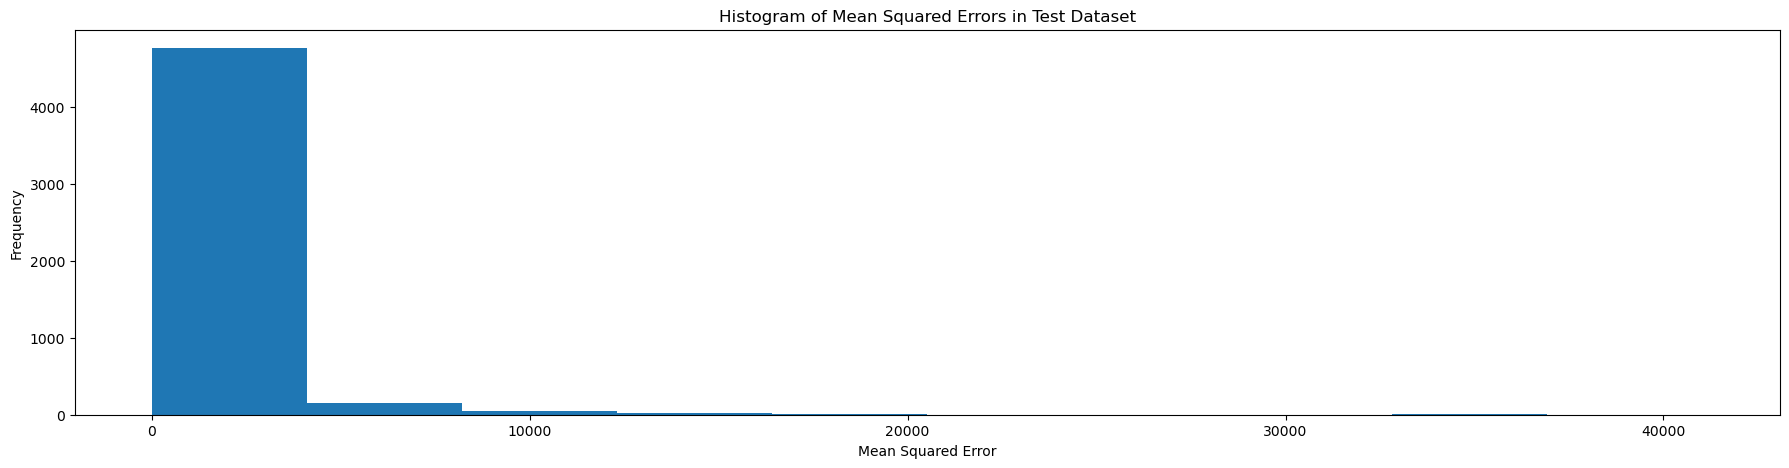

In [69]:
import matplotlib.pyplot as plt

predictions = model.predict([X, X_delays])
error_1 = np.mean(np.square(predictions[0] - X), axis=(1, 2))
error_2 = np.mean(np.abs(predictions[1] - X_delays.reshape(predictions[1].shape)), axis=(1,2))
# error_3 = np.mean(np.abs(predictions[2] - X_prime.reshape(predictions[2].shape)), axis=(1,2))

error = 300*error_1 + error_2 # + error_3

threshold = np.percentile(error, 98)
print(f'Threshold FPR 2%={threshold}')
FPR = len(error[error>threshold])/len(error)
print(f'FPR={FPR}')
# Plotting the histogram of MSE values
print(np.mean(error_1))
print(np.mean(error_2))
print(np.mean(error))
plt.hist(error)
plt.title('Histogram of Mean Squared Errors in Test Dataset')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frequency')
plt.show()

In [165]:
error_3

array([0.03596746, 0.03596746, 0.03596746, ..., 0.03596746, 0.03596747,
       0.03596747])

In [36]:
def get_anomaly_rate(mse, threshold, lengths, num_anomaly_samples_in_session=1):
    index = 0
    anomalies = 0
    for l in lengths:
        sample_anomalies = 0
        for i in range(l):
            if mse[index + i] > threshold:
                sample_anomalies += 1
                if sample_anomalies > num_anomaly_samples_in_session:
                    anomalies += 1
                    break
        index += l
    return anomalies * 1.0 / len(mse)

In [37]:
# predictions = model.predict([X_test, X_delays_test])
# predictions_output_1, predictions_output_2 = predictions

# error1 = np.mean(np.square(y_test - predictions_output_1), axis=1)
# error2 = np.square(y_delays_test - predictions_output_2[:,0])
# error = error1 + error2 #/predictions_output_1.shape[1]

In [38]:
# threshold = 0.161

In [39]:
print(get_anomaly_rate(error, threshold, lengths))

NameError: name 'lengths' is not defined

In [90]:
fpr = get_anomaly_rate(error, threshold, lengths)
print(threshold, fpr)
while fpr < 0.01:
    print(fpr)
    threshold -= 0.001
    fpr = get_anomaly_rate(error, threshold, lengths)
print(f'Threshold = {threshold}')

0.1217297548205496 0.009666413949962092
0.009666413949962092
Threshold = 0.1207297548205496


## Session modification

In [92]:
for i in range(20,21):
    session = sessions[i]
    print(i, session['ip'], session['session_id'])
    for r in session['requests']:
            print(r['ts'], r['url'])

20 66.249.64.131 19gIIfgtbf8AAAAAZhfoeg%3D%3D
2024-04-11 12:41:15 /english/
2024-04-11 12:41:17 /english/
2024-04-11 12:41:27 /


In [95]:
session = sessions[37]
X2, X2_delays = create_dataset(
    [session], 
    # [sessions[90]],
    unique_urls, unique_urls_vectors, datetime_format, num_steps=num_steps)
predictions = model.predict([X2, X2_delays])
error_1 = np.mean(np.square(predictions[0] - X2), axis=(1, 2))
error_2 = np.mean(np.abs(predictions[1] - X2_delays.reshape(predictions[1].shape)), axis=(1,2))
error = error_1 + error_2

print(f'errorTotal_home={error}, \nerror1_home={error_1}, \nerror2_home={error_2}')
print(f'Threshold={threshold}')
print(f"Root MSE: {error}")
print(f'Prediction={error > threshold}')

embedding extra urls...
extra urls = 0
Tokenizing...
Embedding...
vectorizing urls...
unwrapping...
1/1 [==============================] - 0s 26ms/step
errorTotal_home=[0.06695932], 
error1_home=[0.0509472], 
error2_home=[0.01601212]
Threshold=0.6167541518056187
Root MSE: [0.06695932]
Prediction=[False]


## Primary Sessions

Reading from kafka. Host = kavkaz-uzel.eu ... partition = 0
100 sessions read 2024-04-18 20:23:37 1713471820374
200 sessions read 2024-04-18 20:26:28 1713471991901
embedding extra urls...
extra urls = 0
Tokenizing...
Embedding...
vectorizing urls...
unwrapping...
7/7 [==============================] - 0s 19ms/step
FPR=0.065
Threshold=0.02855759169218929
0.007059521339716617
0.004049272839383533
0.035967462063697164


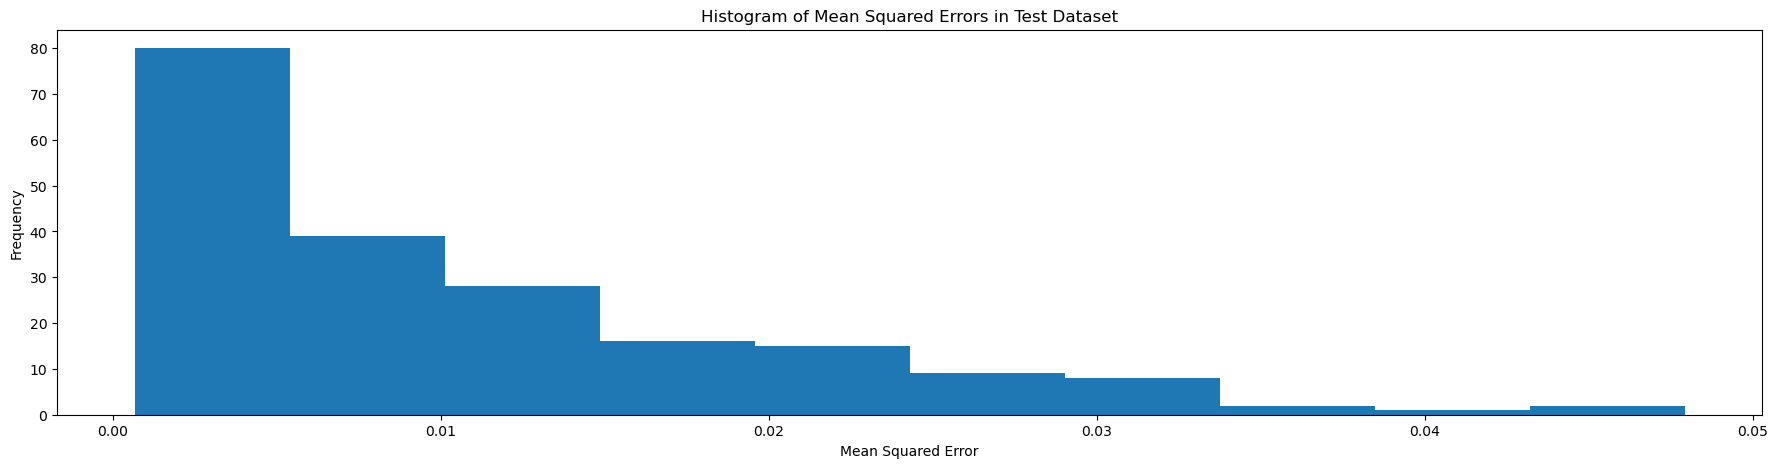

In [277]:
sessions2, ips = read_sessions(
    host = host,
    max_size=200,
    session_type='regular',
    datetime_format=datetime_format
)
X2, X2_delays, X2_prime = create_dataset(sessions2, unique_urls, unique_urls_vectors, datetime_format, host, num_steps=num_steps)
predictions = model.predict([X2, X2_delays])

error_1 = np.mean(np.square(predictions[0] - X2), axis=(1, 2))
error_2 = np.mean(np.abs(predictions[1] - X2_delays.reshape(predictions[1].shape)), axis=(1,2))
# error_3 = np.mean(np.abs(predictions[2] - X2_prime.reshape(predictions[2].shape)), axis=(1,2))

error = error_1 + error_2 #+ error_3

print(f'FPR={len(error[error>threshold]) * 1.0 / len(error)}')
print(f'Threshold={threshold}')
print(np.mean(error_1))
print(np.mean(error_2))
print(np.mean(error_3))
# Plotting the histogram of MSE values
plt.hist(error)
plt.title('Histogram of Mean Squared Errors in Test Dataset')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frequency')
plt.show()

## Another host FPR

Reading from kafka. Host = palestinechronicle.com ... partition = 1
100 sessions read 2024-04-19 04:10:24 1713499826144
200 sessions read 2024-04-19 04:11:23 1713499886848
embedding extra urls...
extra urls = 326
Tokenizing...
Embedding...
vectorizing urls...
unwrapping...
7/7 [==============================] - 0s 33ms/step
FPR=0.095
Threshold=0.11268325823734504
0.01138156466689539
0.009917735610526288
0.010842895252086844


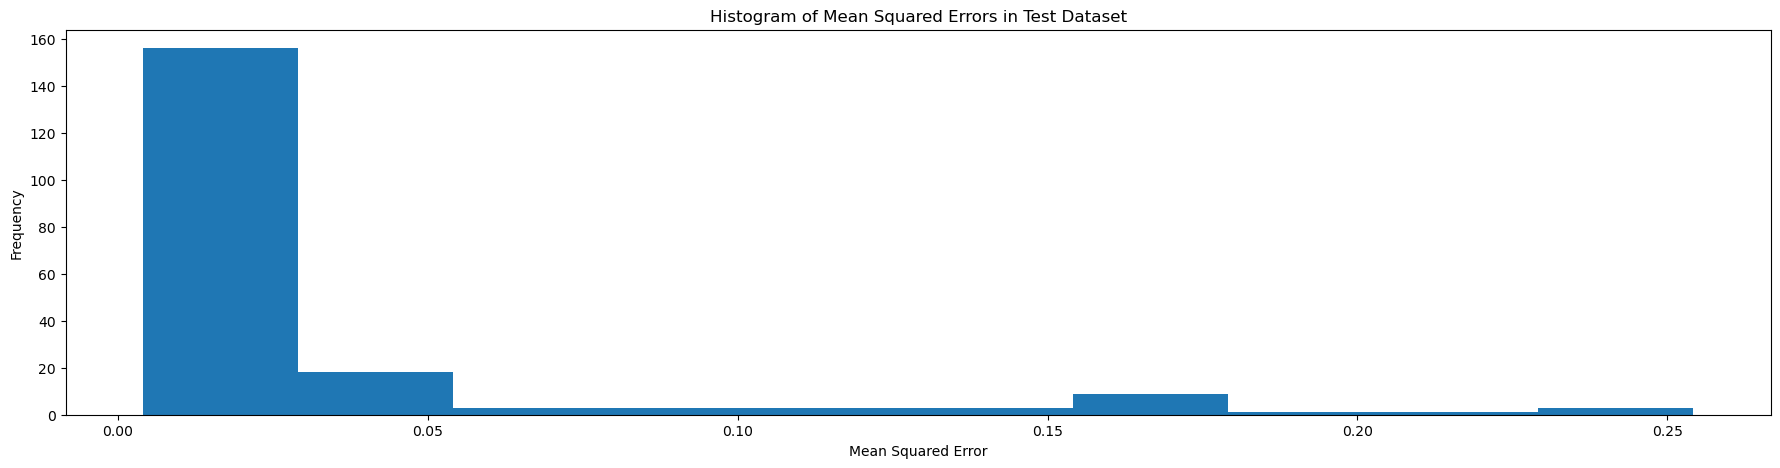

In [47]:
# host2 = 'zhitomir.info'
# host2 = 'btselem.org'
host2 = 'palestinechronicle.com'

sessions2, ips = read_sessions(
    host = host2,
    max_size=200,
    session_type='all',
    datetime_format=datetime_format
)

X2, X2_delays, X2_prime = create_dataset(sessions2, unique_urls, unique_urls_vectors, datetime_format, host2, num_steps=num_steps)
predictions = model.predict([X2, X2_delays, X2_prime])

error_1 = np.mean(np.square(predictions[0] - X2), axis=(1, 2))
error_2 = np.mean(np.abs(predictions[1] - X2_delays.reshape(predictions[1].shape)), axis=(1,2))
error_3 = np.mean(np.abs(predictions[2] - X2_prime.reshape(predictions[2].shape)), axis=(1,2))

error = error_1  + error_2 + error_3

print(f'FPR={len(error[error>threshold]) * 1.0 / len(error)}')
print(f'Threshold={threshold}')
print(np.mean(error_1))
print(np.mean(error_2))
print(np.mean(error_3))
# Plotting the histogram of MSE values
plt.hist(error)
plt.title('Histogram of Mean Squared Errors in Test Dataset')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frequency')
plt.show()

##  Verafile.org home page

In [77]:
session = {
    'duration': 8,
    'primary_session': False,
    'country': 'US',
    'requests': 
    [
        {'ts': '2024-04-10 14:58:14', 'url': '/wp-content/uploads/2024/04/Valor8-800x567.jpg', 'ua': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36', 'query': '', 'code': 304, 'type': '', 'payload': 0, 'method': 'GET'}, 
        {'ts': '2024-04-10 14:58:14', 'url': '/wp-content/uploads/2024/04/MOM-PH-2023-cover-image.jpg', 'ua': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36', 'query': '', 'code': 304, 'type': '', 'payload': 0, 'method': 'GET'}, 
        {'ts': '2024-04-10 14:58:26', 'url': '/specials/fact-check-filipino', 'ua': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 34202, 'method': 'GET'},
        {'ts': '2024-04-10 14:58:32', 'url': '/specials/fact-check-filipino', 'ua': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 34202, 'method': 'GET'},
        {'ts': '2024-04-10 14:58:48', 'url': '/specials/fact-check-filipino', 'ua': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 34202, 'method': 'GET'}
    ]
}

X2, X2_delays = create_dataset(
    [session], 
    # [sessions[90]],
    unique_urls, unique_urls_vectors, datetime_format, host, num_steps=num_steps)
predictions = model.predict([X2, X2_delays])
error_1 = np.mean(np.square(predictions[0] - X2), axis=(1, 2))
error_2 = np.mean(np.abs(predictions[1] - X2_delays.reshape(predictions[1].shape)), axis=(1,2))
error = error_1 + error_2

print(f'errorTotal_home={error}, \nerror1_home={error_1}, \nerror2_home={error_2}')
print(f'timer = {(datetime.now()-ts).total_seconds()}')
print(f'Threshold={threshold}')
print(f"Root MSE: {error}")
print(f'Prediction={error > threshold}')

embedding extra urls...
extra urls = 3
Tokenizing...
Embedding...
vectorizing urls...
unwrapping...


ValueError: too many values to unpack (expected 2)

In [100]:
error.shape

2024-04-10 14:58:14 /wp-content/uploads/2024/04/Valor8-800x567.jpg
2024-04-10 14:58:14 /wp-content/uploads/2024/04/MOM-PH-2023-cover-image.jpg
2024-04-10 14:58:26 /specials/fact-check-filipino


## Home page

In [80]:
duration = 10
hit_rate = 6600
country = 'US'
session = {'duration': duration, 'primary_session': True, 'country': country, 'session_id':'-'}
requests = []
num_hits = int(duration * hit_rate / 60)
ts = datetime.now()
time_increment = 60.0 / hit_rate
countries = []
print(f'Num hits = {num_hits}, duration = {duration} s')
for i in range(num_hits):
    requests.append({'ts': ts, 
                     'url': '/', 
                     # 'url': f'the most important {i}',
                     # 'url': sessions[0]['requests'][0]['url'],
                     'query': '', 'code': 200, 'type': 'text/html','payload': 1000})
    ts += timedelta(seconds=time_increment)
    countries.append(country)
session['requests'] = requests
X2, X2_delays,_ = create_dataset(
    [session], 
    # [sessions[190]],
    unique_urls, unique_urls_vectors, datetime_format, host, num_steps=num_steps)
predictions = model.predict([X2, X2_delays])
error_1 = np.mean(np.square(predictions[0] - X2), axis=(1, 2))
error_2 = np.mean(np.abs(predictions[1] - X2_delays.reshape(predictions[1].shape)), axis=(1,2))
# error_3 = np.mean(np.abs(predictions[2] - X2_prime.reshape(predictions[2].shape)), axis=(1,2))
error = 300*error_1 + error_2 #+ error_3

print(f'errorTotal_home={error}, \nerror1_home={error_1}, \nerror2_home={error_2} ')
print(f'timer = {(datetime.now()-ts).total_seconds()}')
print(f'Threshold={threshold}')
print(f"Root MSE: {error}")
print(f'Prediction={error > threshold}')

Num hits = 1100, duration = 10 s
embedding extra urls...
extra urls = 0
Tokenizing...
Embedding...
vectorizing urls...
unwrapping...
1/1 [==============================] - 0s 31ms/step
errorTotal_home=[44.92198832], 
error1_home=[0.14829711], 
error2_home=[0.43285451] 
timer = -9.394926
Threshold=7504.727685885499
Root MSE: [44.92198832]
Prediction=[False]


In [195]:
np.square(predictions[0] - X2).shape

(1, 15, 128)

In [184]:
X2.shape

(1, 15, 128)

In [42]:
for i in range(len(sessions)):
    s = sessions[i]
    if len(s['requests']) < num_steps + 3:
        continue
    _, X2, X2_delays, y2, y2_delays = create_dataset(
        [s], 
        datetime_format, num_steps=num_steps)
    if X2.shape[0] == 0:
        continue    
    print(len(s['requests']), i)
    predictions = model.predict([X2, X2_delays])
    predictions_output_1, predictions_output_2 = predictions
    
    error1 = np.mean(np.square(y2 - predictions_output_1), axis=1)
    error2 = np.mean(np.square(y2_delays - predictions_output_2[:,0]), axis=0)
    errorTotal = error1 + error2 #/predictions_output_1.shape[1]
    error = np.mean(errorTotal, axis=0)
    print(f"Root MSE: {error}")
    if error > threshold:
        print(session)
        break
    


Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Embedding...
unwrapping...
Tokenizing...
Em

KeyboardInterrupt: 

In [93]:
y2_delays

array([0.0078125, 0.0078125, 0.       , 0.015625 , 0.1171875, 0.       ,
       0.0390625, 0.0703125, 0.0078125, 0.09375  , 0.015625 , 0.0078125,
       0.       , 0.03125  , 0.0078125, 0.       , 0.0859375, 0.1171875,
       0.015625 , 0.09375  , 0.03125  , 0.       , 0.0390625, 0.       ,
       0.0078125, 0.0078125, 0.       , 0.       , 0.0078125, 0.       ,
       0.0234375, 0.0078125, 0.0234375, 0.0703125, 0.015625 , 0.0390625,
       0.015625 , 0.046875 , 0.0234375, 0.015625 , 0.0078125, 0.046875 ,
       0.03125  , 0.0625   , 0.       , 0.015625 , 0.       , 0.0078125,
       0.0078125, 0.       , 0.0078125, 0.       , 0.       , 0.0078125,
       0.       , 0.015625 , 0.       , 0.0078125, 0.015625 , 0.03125  ,
       0.015625 , 0.0078125])

In [94]:
predictions_output_2

array([[-4.63646986e-02],
       [ 1.21090282e-02],
       [-3.59968208e-02],
       [-7.84119405e-03],
       [ 1.17962159e-01],
       [-3.75985689e-02],
       [ 2.53817644e-02],
       [ 1.85257178e-02],
       [-5.18511496e-02],
       [ 8.47426206e-02],
       [ 2.42508035e-02],
       [-4.36094441e-02],
       [-2.54838411e-02],
       [ 1.80113390e-02],
       [-8.21910519e-03],
       [-1.89214870e-02],
       [ 6.66479021e-02],
       [ 8.53596777e-02],
       [ 1.48325302e-02],
       [ 9.75755751e-02],
       [ 1.63974036e-02],
       [-2.59891804e-02],
       [ 2.38322280e-02],
       [-2.03898791e-02],
       [ 5.53515134e-03],
       [-2.02414189e-02],
       [-5.04366448e-03],
       [ 1.93972106e-03],
       [ 2.25331518e-04],
       [-6.96487306e-03],
       [ 8.17924389e-04],
       [ 1.00499075e-02],
       [ 1.22885583e-02],
       [ 3.83698642e-02],
       [ 3.64392623e-03],
       [ 1.75508484e-02],
       [ 1.95696503e-02],
       [ 4.43078838e-02],
       [-2.0

In [87]:
y2_delays

array([0.04261363])

In [88]:
predictions_output_2

array([[-0.05952261]], dtype=float32)

In [211]:
y2_delays - predictions_output_2[:,0]

array([-12.55694771,   0.56258678,   0.56258678,   0.56258678,
         0.56258678,   0.56258678])

In [53]:
predictions = model.predict(X2)
mse_values = np.mean(np.square(predictions - y2), axis=1)

1/1 [==============================] - 0s 30ms/step


In [54]:
mse_values

array([0.01957172, 0.00483445, 0.00483445, 0.00483445, 0.00483445,
       0.00483445, 0.00483445, 0.00483445, 0.00483445, 0.00483445,
       0.00483444, 0.00483444], dtype=float32)

In [67]:
num_home = 0
for s in sessions:
    for r in s['requests']:
        if r['url'] == '/':
            num_home += 1
            print('\n\n ###')
            for r in s['requests']:
                print(r['url'], r['ts'])
print(num_home, num_home * 100.0/len(sessions))



 ###
/articles/vera-files-fact-check-katwiran-ng-palasyo-sa-hindi-pagsama-ng-anibersaryo-ng-people-power-bilang-holiday-nakaliligaw 2024-03-08 04:42:35
/wp-content/uploads/2011/05/liwawa.png 2024-03-08 04:42:35
/articles/vera-files-fact-check-china-did-not-declare-war-vs-philippines 2024-03-08 04:42:40
/articles/vera-files-fact-check-romualdez-misleads-with-claim-that-price-ceiling-on-rice-set-by-marcos-has-affected-world-market 2024-03-08 04:42:53
/articles/vera-files-fact-check-p100-wage-hike-bill-not-yet-law 2024-03-08 04:42:55
/wp-content/uploads/2024/02/022224-FALSE-P100-wage-hike-passed_WEB_ENG.jpg 2024-03-08 04:42:56
/articles/vera-files-fact-check-hindi-inutos-ni-marcos-na-sibakin-ipakulong-o-paalisin-sa-pinas-si-sen-robin 2024-03-08 04:43:04
/wp-content/uploads/2023/10/vffc-confidential-funds-120x120.jpg 2024-03-08 04:43:41
/articles/vera-files-fact-sheet-bakit-kailangan-ang-confidential-at-intelligence-funds 2024-03-08 04:43:41
/articles/violin-prodigy-is-juilliard-bound 20

In [94]:

# Predict the next value (two-dimensional vector)
next_vector = model.predict(X[-num_steps:])[0]
print(f"Predicted next vector: {next_vector}")

1/1 [==============================] - 0s 26ms/step
Predicted next vector: [ 0.07221214  0.21693999  0.0784342   0.02563586  0.01143848 -0.18851225
  0.00611085  0.06646264 -0.1842081   0.09987619  0.04800044 -0.08932969
  0.1495375   0.15877268 -0.16429386  0.07818806  0.02932158  0.22956209
 -0.08299863 -0.11680726 -0.04841654  0.20351145 -0.14615172  0.05819415
 -0.08108544 -0.25210527 -0.24348718  0.27957487  0.15510416 -0.12804295
 -0.01280112 -0.12317632  0.14704691 -0.08027183 -0.22006027 -0.12634699
 -0.02456348 -0.12193092  0.08169118  0.1151506   0.0816001  -0.06002513
  0.3089745  -0.04447167 -0.09063466  0.16466685 -0.04610489 -0.07550969
 -0.00437683  0.0568261   0.05710223 -0.06307752  0.01604434  0.01055181
  0.16776983  0.3716555   0.21914153 -0.08170818 -0.00206302  0.10620315
 -0.07822333  0.07009785  0.01712641 -0.13944215  0.09832448 -0.08370674
  0.00940936 -0.12211141  0.03378075  0.16626726 -0.04200068  0.22686541
 -0.04942314 -0.11571244 -0.21995898 -0.21605985 

In [93]:
X[-num_steps:].shape

(2, 2, 300)

In [71]:
y.shape

(64, 300)

In [48]:
session_vectors = session_to_vec(
    sessions[0], 
    warmup_period=3, 
    datetime_format=datetime_format,
    model_embeddings=model_embeddings
)

In [55]:
for session in sessions:

SyntaxError: incomplete input (745880440.py, line 1)

In [51]:
session_vectors_to_samples(session_vectors, 1)

([[array([-3.43802311e-02,  7.93091953e-02,  5.75114675e-02,  9.45826918e-02,
          -1.12461634e-01, -9.28737074e-02, -9.30698961e-02, -2.08312988e-01,
           1.31081715e-01,  2.51922607e-02,  3.60717773e-02, -5.61152846e-02,
          -2.67181396e-02, -3.53480726e-02, -1.46885455e-01,  8.16301629e-02,
           8.92377570e-02,  8.03397000e-02,  7.18296617e-02, -1.61612377e-01,
          -1.20082311e-01,  1.80332720e-01,  4.21883725e-02,  5.07812500e-02,
           8.11767578e-02, -1.61307231e-02, -3.65557000e-02,  7.95211792e-02,
           2.63366699e-02,  4.73458432e-02, -1.05555944e-01,  4.24630381e-03,
          -4.16913703e-02, -1.60086498e-01,  3.04957759e-03,  3.49295475e-02,
          -2.82767154e-02,  4.29861918e-02, -5.63441701e-02,  1.00620814e-01,
           1.68831959e-01, -3.71180959e-02,  1.81483686e-01,  9.10688117e-02,
           3.98646779e-02,  1.59563348e-02, -1.27463207e-01,  1.41601562e-02,
          -2.76227687e-02,  1.33283347e-01,  2.58440301e-02,  7.

In [31]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.model_selection import train_test_split

def create_dataset(sequence, n_steps):
    X, y = [], []
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1:
            break
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

# Generating a synthetic sequence of two-dimensional vectors
sequence = [[i, i] for i in range(100)]  # Replace with your sequence
n_steps = 5  # Number of time steps in the sequence

# Prepare the dataset
X, y = create_dataset(sequence, n_steps)

# Each input sample is a sequence of n_steps vectors, each with 2 dimensions
input_shape = (n_steps, 2)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Define the GRU model
model = Sequential([
    GRU(50, activation='relu', input_shape=input_shape),
    Dense(2)  # Output layer with 2 units for the two-dimensional vector
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Fit the model
model.fit(X_train, y_train, epochs=200, verbose=0)

# Evaluate the model
mse = model.evaluate(X_test, y_test, verbose=0)
print(f"Mean Squared Error: {mse}")

# Predict the next value (two-dimensional vector)
next_vector = model.predict(np.array([sequence[-n_steps:]]))[0]
print(f"Predicted next vector: {next_vector}")


Mean Squared Error: 0.0031195098999887705
1/1 [==============================] - 0s 199ms/step
Predicted next vector: [100.00126 100.01248]


In [80]:
X[-n_steps:].shape

(5, 2, 300)